---
title: Find the Maximum Independent Set with the Aqarios Constrained Quantum Optimizer
description: Use Aqarios Constrained Quantum Optimizer based on iterative warm-starting and XY-mixers to solve the Maximum Independent Set problem on IBM Quantum hardware
---

{/* cspell:ignore Aqarios QOBLIB Bucher forall */}

# Find the Maximum Independent Set with the Aqarios Constrained Quantum Optimizer

<Admonition type="note" title="Note">
  Qiskit Functions are an experimental feature available only to IBM Quantum&reg; Premium Plan, Flex Plan, and On-Prem (via IBM Quantum Platform API) Plan users. They are in preview release status and subject to change.
</Admonition>

*Usage estimate: 30 seconds on a Heron r2 processor. (NOTE: This is an estimate only. Your runtime might vary.)*

## Background

This tutorial demonstrates how to find the maximum independent set of a graph using the [Aqarios Constrained Quantum Optimizer](/docs/guides/aqarios-constrained-quantum-optimizer) [\[1\]](#references), a constrained combinatorial optimization problem.
An instance from the QOBLIB [\[2\]](#references) benchmark library is formulated as a binary linear program and passed to the Optimizer Application Function.
The optimizer handles all reformulation, circuit synthesis, transpilation, and iterative warm starting internally (see [\[3\]](#references) for details).

The tutorial covers the following steps:

1. Define the problem as a linear program using the `OptimizationProblem` from [qiskit-addon-opt-mapper](https://github.com/qiskit/qiskit-addon-opt-mapper)
2. Run the quantum optimization using the Aqarios Constrained Quantum Optimizer
3. Retrieve and visualize the results

### The Maximum Independent Set problem

The Maximum Independent Set (MIS) problem is a fundamental challenge in combinatorial optimization.
Formally, given a graph $G(V, E)$, the goal is to find the largest subset of vertices $V_I \subset V$ such that no two vertices in $V_I$ are connected by an edge, as in $\nexists (u, v) \in E : v \in V_I \wedge u \in V_I$.
Each vertex is assigned a binary decision variable $x_i \in \{0, 1\}$, and a constraint $x_u + x_v \leq 1$ is introduced for every edge, ensuring that at most one endpoint of each edge is selected.
The problem can thus be stated as the following maximization problem:
$$
\max_{x_i} \sum_{i \in V} x_i \qquad\text{(find the largest set)}\\
\text{s.t.} \quad x_u + x_v \leq 1 \quad \forall (u, v) \in E.
$$

MIS has a wide range of practical applications. In wireless network planning, an independent set corresponds to a group of transmitters that can all broadcast simultaneously without mutual interference. In scheduling, it models the largest collection of tasks that can execute concurrently given pairwise resource conflicts. In computational biology, it captures sets of mutually non-interacting proteins in a network.

Despite its intuitive formulation, MIS is NP-hard, and even for graphs with a few hundred nodes specific instances become difficult to solve exactly or heuristically [\[2\]](#references).
The problem also gives rise to sparse constraint structures that are well suited for hardware implementations of quantum optimization, making it an attractive benchmark for near-term quantum devices.

### Aqarios Constrained Quantum Optimizer

The standard approach to embedding a constrained binary problem into quantum optimization transforms the model into an unconstrained format by adding penalty terms: each violated constraint $x_u + x_v \leq 1$ contributes $2 x_u x_v$ to the minimization objective $-\sum_i x_i$. This is handled automatically by the Constrained Quantum Optimizer Qiskit Function.

Beyond this standard transformation, the optimizer identifies **cliques** in the constraint graph. A clique is a set of nodes $V_C$ where every pair of nodes shares an edge. As a consequence, the $\binom{|V_C|}{2}$ pairwise constraints $x_u + x_v \leq 1 \;\forall (u,v) \in E_C$ can be replaced by a single, tighter constraint $\sum_{i \in V_C} x_i \leq 1$. Introducing a slack variable $y$ turns this into an equality $\sum_i x_i + y = 1$, which takes the form of a one-hot constraint that can be enforced directly in QAOA using **XY-mixers** [\[3\]](#references). This reduces the search space and avoids the need for penalty terms for those constraints, improving solution quality.

Additionally, variables connected to only a single neighbor are called **pendant** nodes and are fixed deterministically by the algorithm before quantum execution, further reducing the effective problem size.

The Constrained Quantum Optimizer employs an **iterative warm-starting** approach compatible with XY-mixers [\[1\]](#references), which progressively narrows the search space by biasing the quantum state distribution towards promising solution regions across iterations. This enables the use of **fixed-angle QAOA parameters**, eliminating the need for variational parameter training. The total quantum resource requirements are governed solely by the number of warm-start iterations, which means the quantum cost straightforward to control.

## Requirements

Before starting this tutorial, ensure that you have installed the following requirements:

* Qiskit Runtime (`pip install qiskit-ibm-runtime`)
* Qiskit Functions Catalog IBM Client (`pip install qiskit-ibm-catalog`)
* Qiskit Addon Optimization Mapper (`pip install qiskit-addon-opt-mapper`)
* Numpy (`pip install numpy`)
* Matplotlib (`pip install matplotlib`)
* NetworkX (`pip install networkx`)

Optionally, for the [Appendix](#appendix-problem-statement-with-luna-model) you need to install

* Luna Model (`pip install luna-model`)

## Setup

Import all required dependencies.

In [1]:
import networkx as nx
import urllib.request

from qiskit_ibm_catalog import QiskitFunctionsCatalog

from qiskit_addon_opt_mapper import OptimizationProblem
from qiskit_addon_opt_mapper.applications import IndependentSet
from qiskit_addon_opt_mapper.translators import to_docplex_mp

First, authenticate using your [IBM Quantum API key](http://quantum.cloud.ibm.com/). Then, select the Qiskit Function as follows. (This code assumes you've already [saved your account](/docs/guides/functions-get-started#install-qiskit-functions-catalog-client) to your local environment.)

In [2]:
catalog = QiskitFunctionsCatalog(channel="ibm_quantum_platform")

# Verify that you have access to the function
catalog.list()

[QiskitFunction(aqarios/constrained-quantum-optimizer)]

In [3]:
# Load the function
optimizer = catalog.load("aqarios/constrained-quantum-optimizer")

In [4]:
# Check the list of backends you have access to
catalog.backends()

[<IBMBackend('ibm_pittsburgh')>,
 <IBMBackend('ibm_boston')>,
 <IBMBackend('ibm_phoenix')>,
 <IBMBackend('ibm_fez')>,
 <IBMBackend('ibm_miami')>,
 <IBMBackend('ibm_marrakesh')>,
 <IBMBackend('ibm_kingston')>]

In [5]:
# Select the backend you want to use
backend = catalog.backend("ibm_pittsburgh")

## Step 1: Map classical inputs to quantum problem

The problem is formulated as an **LP-file**, a common format for optimization problems that serves as the input to the Aqarios Constrained Quantum Optimizer. Besides LP-files, the function also supports **MPS-files** and native **Luna Model** representations.
The LP-file is generated through the following steps:

1. Fetch a graph instance from the QOBLIB [\[2\]](#references)
2. Model the optimization problem
3. Generate the LP-file

### Load the problem instance graph

The graphs are specified in the DIMACS `.gph` format, a line-based format where lines starting with `e` define edges, lines starting with `p` define the problem header, and lines starting with `c` are comments:
```
c some-comment
p edge 3 2
e 1 2
e 2 3
...
```

The `.gph` file can be downloaded from the QOBLIB repository using the following function, which also parses it into a NetworkX graph. Note that the DIMACS format uses 1-based node labeling, which is converted to 0-based indexing here.

In [6]:
URL_BASE = "https://raw.githubusercontent.com/ZIB-AOPT/QOBLIB/refs/heads/main/07-independentset/instances/"


def fetch_qoblib_graph(name: str) -> nx.Graph:
    """Fetch and parse the QOBLIB graph file."""
    # Download the .gph file
    file, _ = urllib.request.urlretrieve(URL_BASE + f"{name}.gph")
    with open(file) as f:
        # Read the file contents
        lines = f.readlines()

    # Skip comments
    lines = [line for line in lines if not line.startswith("c")]

    # Read graph definition
    _, _, num_nodes, num_edges = lines[0].split()
    print(f"Loading graph with {num_nodes} nodes and {num_edges} edges.")

    # Parse edge information
    # The .gph format starts node labeling with 1; we need 0 here, so we subtract one.
    split_edges = (line.split() for line in lines[1:])
    edges = [(int(u) - 1, int(v) - 1) for _, u, v in split_edges]

    return nx.Graph(edges)


graph_name = "es60fst02"
graph = fetch_qoblib_graph(graph_name)

Loading graph with 186 nodes and 280 edges.


This example uses the `es60fst02` instance from QOBLIB, a graph with 186 nodes and 280 edges. Thanks to the preprocessing steps employed by the Constrained Quantum Optimizer, this instance is solvable on 156-qubit Heron devices. The graph can be visualized using matplotlib:

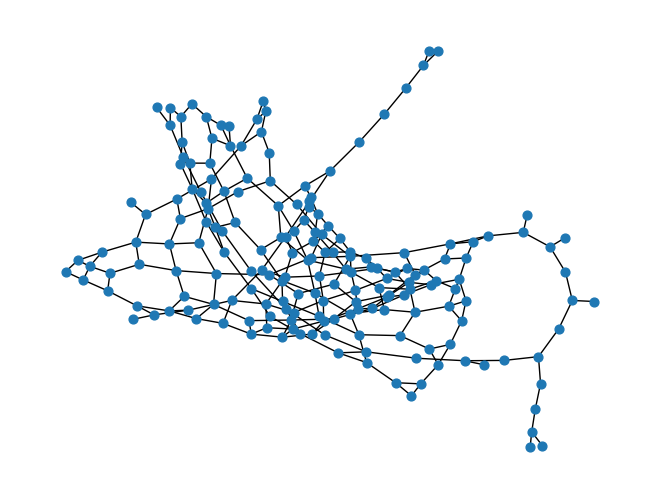

In [7]:
# Keep layout for later reuse
layout = nx.spring_layout(graph, seed=1)
nx.draw(graph, layout, node_size=40)

### Construct the optimization problem

The Maximum Independent Set problem can be formulated directly using `OptimizationProblem`. Each graph node becomes a binary decision variable, and each edge introduces a constraint ensuring that at most one of its endpoints is selected:

In [8]:
# Create an OptimizationProblem instance
mis_problem = OptimizationProblem("MIS")

# Add a binary variable for each node
x = mis_problem.binary_var_list(graph.number_of_nodes())

# Maximize the sum of all node variables
mis_problem.maximize(linear={xi.name: 1 for xi in x})

# Add '<= 1' constraints for each edge
for u, v in graph.edges:
    mis_problem.linear_constraint({x[u].name: 1, x[v].name: 1}, "<=", 1)

#### A shortcut

The [`qiskit-addon-opt-mapper`](https://qiskit.github.io/qiskit-addon-opt-mapper/) package provides a pre-implemented application class for the Maximum Independent Set problem, which simplifies the formulation above into a single call:

In [9]:
mis = IndependentSet(graph)
mis_problem = mis.to_optimization_problem()

### Translate the problem to an LP-file

The `OptimizationProblem` itself does not support LP-file exports, but it is interoperable with [DOcplex](https://www.ibm.com/docs/de/icos/22.1.2?topic=docplex-python-modeling-api), which does. Generating the LP-file contents requires only two lines:

In [10]:
mp_model = to_docplex_mp(mis_problem)
lp_str = mp_model.export_as_lp_string()

print("\n".join(lp_str.split("\n")[:60]))
print("...")

\ This file has been generated by DOcplex
\ ENCODING=ISO-8859-1
\Problem name: Independent set

Maximize
 obj: x_0 + x_1 + x_2 + x_3 + x_4 + x_5 + x_6 + x_7 + x_8 + x_9 + x_10 + x_11
      + x_12 + x_13 + x_14 + x_15 + x_16 + x_17 + x_18 + x_19 + x_20 + x_21
      + x_22 + x_23 + x_24 + x_25 + x_26 + x_27 + x_28 + x_29 + x_30 + x_31
      + x_32 + x_33 + x_34 + x_35 + x_36 + x_37 + x_38 + x_39 + x_40 + x_41
      + x_42 + x_43 + x_44 + x_45 + x_46 + x_47 + x_48 + x_49 + x_50 + x_51
      + x_52 + x_53 + x_54 + x_55 + x_56 + x_57 + x_58 + x_59 + x_60 + x_61
      + x_62 + x_63 + x_64 + x_65 + x_66 + x_67 + x_68 + x_69 + x_70 + x_71
      + x_72 + x_73 + x_74 + x_75 + x_76 + x_77 + x_78 + x_79 + x_80 + x_81
      + x_82 + x_83 + x_84 + x_85 + x_86 + x_87 + x_88 + x_89 + x_90 + x_91
      + x_92 + x_93 + x_94 + x_95 + x_96 + x_97 + x_98 + x_99 + x_100 + x_101
      + x_102 + x_103 + x_104 + x_105 + x_106 + x_107 + x_108 + x_109 + x_110
      + x_111 + x_112 + x_113 + x_114 + x_115 + x_116

This format is native to the Constrained Quantum Optimizer.

## Step 2: Optimize problem for quantum hardware execution

All circuit synthesis, optimization, and transpilation is handled by the function natively. See the [inputs section](/docs/api/functions/aqarios-constrained-quantum-optimizer#inputs) in the API reference for the arguments with which to call the function.

To fine-tune the algorithm's behavior, see the [Options list](/docs/api/functions/aqarios-constrained-quantum-optimizer#options-list) in the API reference.

For more information, see the [Aqarios Constrained Quantum Optimizer guide](/docs/guides/aqarios-constrained-quantum-optimizer) and [API reference](/docs/api/functions/aqarios-constrained-quantum-optimizer).

## Step 3: Execute using Qiskit primitives

The LP-file can now be submitted to the optimizer:

In [11]:
job = optimizer.run(model=lp_str, backend_name=backend.name)

print(f"Job ID: {job.job_id}")

Job ID: 87ec08b9-6275-40fa-be94-340a0a916bf1


Internally, the algorithm proceeds through the following stages:

1. **Preprocessing**:
    - Reduce fixable variables
    - Find cliques
    - Identify constraint types
    - Evaluate penalty factors for penalty terms
    - Apply constraint transformations
    - Synthesize circuit with constraint-enforcing methods
    - Approximation of the problem and transpilation
2. **Parallel chains of iterative loops**:
    - Sample from circuit with fixed parameters
    - Apply postprocessing
    - Evaluate and set new warm-starting probabilities
3. **Postprocessing**:
    - Find best samples and check for feasibility with regards the input problem

### Monitor the progress

See the following sections in the Get started with Qiskit Functions page to monitor your job's progress:

- [Check job status](/docs/guides/functions-get-started#check-job-status)
- [Retrieve results](/docs/guides/functions-get-started#retrieve-results)

In [12]:
# Monitor the job status
job.status()

'QUEUED'

## Step 4: Post-process and return results in desired classical format

The result output is a dictionary, the fields of which are described in the [Outputs section](/docs/api/functions/aqarios-constrained-quantum-optimizer#outputs) of the API reference.

When the [`solutions`](/docs/api/functions/aqarios-constrained-quantum-optimizer#output-structure) list contains more than one entry, multiple degenerate optima have been found. Only the first solution is considered here:

In [13]:
# Retrieve the job result
result = job.result()

# Retrieve the first solution from the result
solution = result["solutions"][0]

print(f"The found maximum independent set of {graph_name} contains:", end=" ")
print(
    f"{int(result['obj_value'])} nodes and is {'feasible' if result['feasible'] else 'infeasible'}."
)
print("{" + " ".join(k[2:] for k, v in solution.items() if v == 1) + "}")

The found maximum independent set of es60fst02 contains: 88 nodes and is feasible.
{100 103 107 109 111 113 115 118 121 123 124 127 129 130 132 133 138 142 144 148 149 155 156 16 161 162 165 167 169 170 175 28 31 33 35 36 47 50 58 59 60 62 64 66 68 71 73 75 78 79 84 85 87 90 91 93 94 95 39 5 27 23 43 15 22 9 4 56 32 30 53 26 17 54 1 37 41 49 34 11 139 153 12 3 6 57 20 44}


### Visualization

The identified independent set can be visualized by highlighting the selected nodes in the graph:

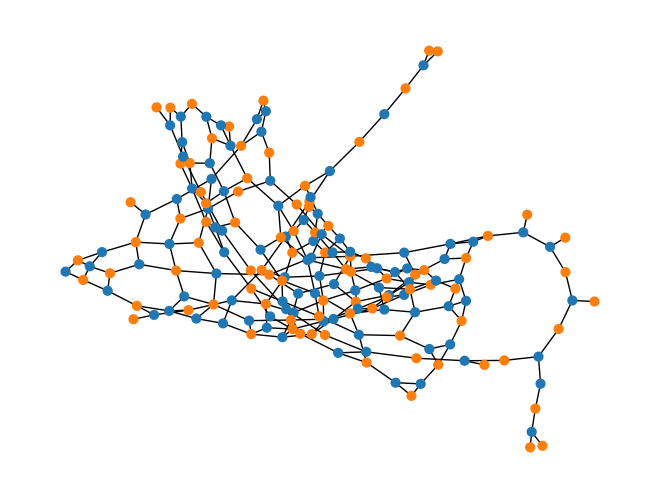

In [14]:
# Color all selected nodes in orange
node_map = {
    int(k.split("_")[1]): "tab:orange" if v else "tab:blue" for k, v in solution.items()
}
node_colors = [node_map[k] for k in graph.nodes]

# Draw with the same layout used before
nx.draw(graph, layout, node_size=40, node_color=node_colors)

## Appendix: Problem statement with Luna Model

In addition to the `qiskit-addon-opt-mapper` approach shown above, the Qiskit Function also accepts models created with Luna Model [\[4\]](#references), Aqarios' modeling SDK.
After installation of the `luna-model` PyPI package, import it as follows:

**Setup:**

In [15]:
from luna_model import Model, Sense
import numpy as np

The model is then constructed from the graph in the same way as with `qiskit-addon-opt-mapper`:

**Build the model:**

In [ ]:
edges = np.array(graph.edges)

# Create the optimization model with a name
model = Model(name=f"MIS-{graph_name}", sense=Sense.MAX)
# Add binary variables
x = model.add_variables("x", graph.number_of_nodes())
# Set the objective
model.objective = x.sum()

# Use numpy like batch generation of constraints
model.add_constraints(x[edges].sum(axis=1) <= 1)

input_str = model.encode_b64()

# optimizer.run(model=input_str, backend_name="ibm_fez")

## Next Steps

<Admonition type="tip" title="Recommendations">
- Consult the [Aqarios Constrained Quantum Optimizer guide](/docs/guides/aqarios-constrained-quantum-optimizer) for a detailed walkthrough of all function features.
- Explore the [API reference](/docs/api/functions/aqarios-constrained-quantum-optimizer) for the full list of input parameters and output fields.
- Experiment with the algorithm options (`reps`, `num_parallel`, `shots`, `postprocessing`) on your own constrained binary optimization problem to assess their impact on solution quality and runtime.
</Admonition>

## References

1. IBM Quantum, [*Aqarios Constrained Quantum Optimizer Guide*](/docs/guides/aqarios-constrained-quantum-optimizer)
2. Koch et al. (2026), *The Quantum Optimization Benchmarking Library* [10.1038/s43588-026-00991-1](https://doi.org/10.1038/s43588-026-00991-1)
3. Bucher et al. (2026), *Constrained Quantum Optimization via Iterative Warm-Start XY-Mixers* [10.1088/1367-2630/ae8ea2](https://doi.org/10.1088/1367-2630/ae8ea2)
4. Aqarios GmbH, [*Luna Model Docs*](https://docs.aqarios.com/luna-model)